In [1]:
import pandas as pd
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten
from tensorflow.keras import backend as K

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

(x_train,y_train),(x_test,y_test)=mnist.load_data()

x-train [Shape(60000, 28, 28)] sample patch 
 [[  0  76 246 252 112]
 [  0  85 252 230  25]
 [  0  85 252 223   0]
 [  0  85 252 145   0]
 [  0  86 253 225   0]]


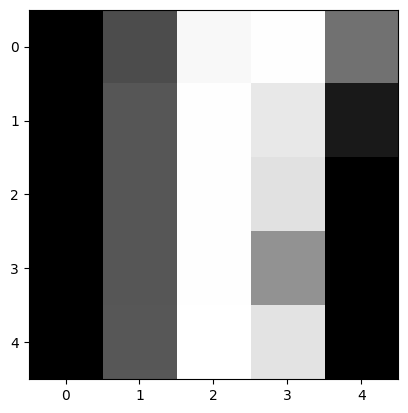

In [3]:
import matplotlib.pyplot as plt
print("x-train [Shape%s] sample patch \n"% (str(x_train.shape)),x_train[1,15:20,5:10])
plt.imshow(x_train[1,15:20,5:10],cmap='gray')
plt.show()

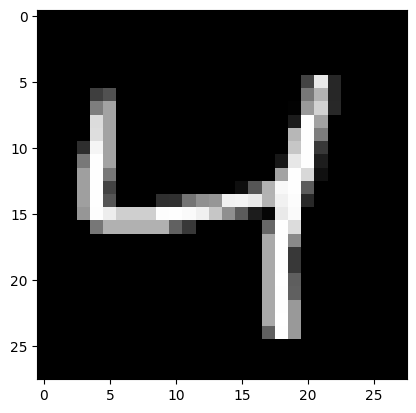

In [5]:
plt.imshow(x_train[2],cmap='gray')
plt.show()

In [12]:
import tensorflow as tf
# Load and preprocess the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32')/255.0 #scaling min max scaler
x_test = x_test.astype('float32')/255.0
#flatten the image (28*28 into 784)
x_train = x_train.reshape(x_train.shape[0],-1)
x_test = x_test.reshape(x_test.shape[0],-1)

# one-hot encoding lable
y_train=tf.keras.utils.to_categorical(y_train,num_classes=10)
y_test=tf.keras.utils.to_categorical(y_test,num_classes=10)

model = tf.keras.Sequential([
   tf.keras.layers.Dense(200,activation='relu',input_shape=(784,)),
   tf.keras.layers.Dense(100,activation='relu'),
   tf.keras.layers.Dense(60,activation='relu'),
   tf.keras.layers.Dense(30,activation='relu'),
   tf.keras.layers.Dense(10,activation='softmax')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 200)            │       157,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 60)             │         6,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           310 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185,300 (723.83 KB)

 Trainable params: 185,300 (723.83 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# back propagation
model.compile(optimizer=tf.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [14]:
history = model.fit(x_train,y_train,epochs=10,batch_size=64,validation_split=0.2)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.9069 - loss: 0.3061 - val_accuracy: 0.9505 - val_loss: 0.1626
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9652 - loss: 0.1144 - val_accuracy: 0.9654 - val_loss: 0.1143
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9766 - loss: 0.0785 - val_accuracy: 0.9686 - val_loss: 0.1122
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9810 - loss: 0.0618 - val_accuracy: 0.9704 - val_loss: 0.0992
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9848 - loss: 0.0474 - val_accuracy: 0.9734 - val_loss: 0.0971
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9875 - loss: 0.0385 - val_accuracy: 0.9699 - val_loss: 0.1132
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9900 - loss: 0.0330 - val_accuracy: 0.9757 - val_loss: 0.0989
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9913 - loss: 0.0260 - val_accuracy: 0

In [ ]:
test_loss,test_acc= model.evaluate(x_test,y_test)
print('Test accuracy: {test_acc}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9739 - loss: 0.1148
Test accuracy : {test_acc}


In [16]:
import numpy as np 
def get_random_indices(total_images,num_images):
   indices = np.random.choice(total_images,num_images,replace=False)
   return indices 

In [17]:
predictions = model.predict(x_test)
x_test_images = x_test.reshape(-1,28,28)
prediction_classes=np.argmax(predictions,axis=1)
true_classes = np.argmax(y_test,axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [18]:
from numpy.random import f
num_images_to_show = 5
random_indices = get_random_indices(len(x_test_images),num_images_to_show)
def plot_images(images,labels,predictions):
   plt.figure(figsize=(10,9))
   for i in range(len(images)):
      plt.subplot(1,len(images),i+1)
      plt.imshow(images[i],cmap='gray')
      plt.title(f'Actual:{labels[i]},\n Prediction {predictions[i]}')
      plt.axis('off')
   plt.show()

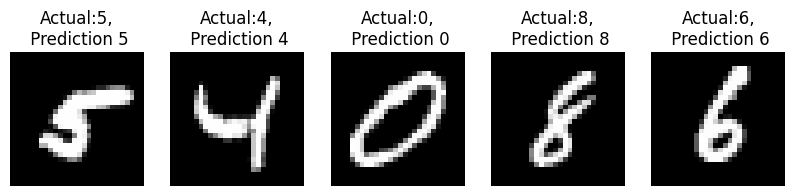

In [19]:
plot_images(x_test_images[random_indices],true_classes[random_indices],prediction_classes[random_indices]) 

In [20]:
import tensorflow as tf
# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
 
x_train = x_train.astype('float32') / 255.0# scaling min max scaler
x_test = x_test.astype('float32') /255.0
#flatten the images (28*28 into 784)
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)
#one - hot encoding labels
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)
 
model = tf.keras.Sequential([
    tf.keras.layers.Dense(200, activation = 'relu', input_shape =(784,)),
    tf.keras.layers.Dense(100, activation = 'relu'),
    tf.keras.layers.Dense(60, activation = 'relu'),
    tf.keras.layers.Dense(30, activation = 'relu'),
    tf.keras.layers.Dense(10, activation = 'softmax')
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
historty = model.fit(x_train,y_train, epochs =10, batch_size=64, validation_split=0.2)
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc}')
#

d:\git\depi\DEBI-ONL4_AIS2_S2\.pyt\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.6796 - loss: 0.9830 - val_accuracy: 0.8033 - val_loss: 0.6284
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8239 - loss: 0.5767 - val_accuracy: 0.8646 - val_loss: 0.4618
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8783 - loss: 0.4159 - val_accuracy: 0.9056 - val_loss: 0.3287
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9087 - loss: 0.3110 - val_accuracy: 0.9152 - val_loss: 0.2757
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9240 - loss: 0.2550 - val_accuracy: 0.9338 - val_loss: 0.2260
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9363 - loss: 0.2149 - val_accuracy: 0.9401 - val_loss: 0.2052
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9450 - loss: 0.1839 - val_accuracy: 0.9443 - val_loss: 0.1856
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9519 - loss: 0.1610 - val_accuracy: 0.

In [23]:
pip install TensorBoard

   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.5 MB ? eta -:--:--
   --------- ------------------------------ 1.3/5.5 MB 4.2 MB/s eta 0:00:02
   ----------- ---------------------------- 1.6/5.5 MB 4.2 MB/s eta 0:00:01
   ---------------------- ----------------- 3.1/5.5 MB 4.2 MB/s eta 0:00:01
   ------------------------------ --------- 4.2/5.5 MB 4.6 MB/s eta 0:00:01
   ------------------------------------ --- 5.0/5.5 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 5.5/5.5 MB 4.2 MB/s  0:00:01

   ------------- -------------------------- 1/3 [markdown]
   ------------- -------------------------- 1/3 [markdown]
   ------------- -------------------------- 1/3 [markdown]
   ------------- -------------------------- 1/3 [markdown]
   ------------- -------------------------- 1/3 [markdown]
   ------------- -------------------------- 

In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import TensorBoard
# list_activation = {'sigmoid','relu','tanh'}
# list_optimizers = {'adam','rmsprop'}
NAME = 'mnist-28-28-v1'
tensorboard = TensorBoard(log_dir='logs/{}'.format(NAME))
# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
 
x_train = x_train.astype('float32') / 255.0# scaling min max scaler
x_test = x_test.astype('float32') /255.0
#flatten the images (28*28 into 784)
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)
#one - hot encoding labels
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

  
model = tf.keras.Sequential([
    tf.keras.layers.Dense(200, activation = 'relu', input_shape =(784,)),
    tf.keras.layers.Dense(100, activation = 'relu'),
    tf.keras.layers.Dense(60, activation = 'relu'),
    tf.keras.layers.Dense(30, activation = 'relu'),
    tf.keras.layers.Dense(10, activation = 'softmax')
])
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
historty = model.fit(x_train,y_train, epochs =10, batch_size=64, validation_split=0.2, callbacks=[tensorboard])
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f'Test accuracy: {test_acc}')
#

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.1125 - loss: 2.3015 - val_accuracy: 0.1060 - val_loss: 2.3019
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.1140 - loss: 2.3012 - val_accuracy: 0.1060 - val_loss: 2.3022
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3020
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3025
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3022
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3023
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.

In [27]:
!tensorboard --logdir = logs --port = 6006

d:\git\depi\DEBI-ONL4_AIS2_S2\.pyt\Lib\site-packages\tensorboard\default.py:30: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
I0000 00:00:1776818990.618403    7368 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776818994.870301    7368 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
usage: tensorboard [-h] [--helpfull] [--logdir PATH] [--logdir_spec PATH_SPEC]
              

In [28]:
import tensorflow as tf
from tensorflow.keras.callbacks import TensorBoard
list_activation = {'sigmoid','relu','tanh'}
list_optimizers = {'adam','rmsprop'}
NAME = 'mnist-28-28-v1'
tensorboard = TensorBoard(log_dir='logs/{}'.format(NAME))
# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
 
x_train = x_train.astype('float32') / 255.0# scaling min max scaler
x_test = x_test.astype('float32') /255.0
#flatten the images (28*28 into 784)
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)
#one - hot encoding labels
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

  
i = 1 
for activation in list_activation:
    for optimizer in list_optimizers:
        NAME = f'{activation}-{optimizer}-{i}'
        i += 1
        print('NAME: ',NAME)
        model = tf.keras.Sequential([
            tf.keras.layers.Dense(200, activation = 'relu', input_shape =(784,)),
            tf.keras.layers.Dense(100, activation = 'relu'),
            tf.keras.layers.Dense(60, activation = 'relu'),
            tf.keras.layers.Dense(30, activation = 'relu'),
            tf.keras.layers.Dense(10, activation = 'softmax')
        ])
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])
        historty = model.fit(x_train,y_train, epochs =10, batch_size=64, validation_split=0.2, callbacks=[tensorboard])
        test_loss, test_acc = model.evaluate(x_test, y_test)
        print(f'Test accuracy: {test_acc}')
        #

NAME:  tanh-rmsprop-1


d:\git\depi\DEBI-ONL4_AIS2_S2\.pyt\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.1127 - loss: 2.3016 - val_accuracy: 0.1060 - val_loss: 2.3022
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1140 - loss: 2.3012 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3020
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3023
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.

In [30]:
!tensorboard --logdir=logs --port=6006

^C
